# GRAD50500 Week 3 Assignment
## Sarah Card

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

iris_df = sns.load_dataset('iris')

data = { "weight": [4.17, 5.58, 5.18, 6.11, 4.50, 4.61, 5.17, 4.53, 5.33, 5.14, 4.81, 4.17, 4.41, 3.59, 5.87, 3.83, 6.03, 4.89, 4.32, 4.69, 6.31, 5.12, 5.54, 5.50, 5.37, 5.29, 4.92, 6.15, 5.80, 5.26], "group": ["ctrl"] * 10 + ["trt1"] * 10 + ["trt2"] * 10}
PlantGrowth = pd.DataFrame(data)

## 1: Using the iris dataset...

### 1A: Make a histogram of the variable Sepal.Width.

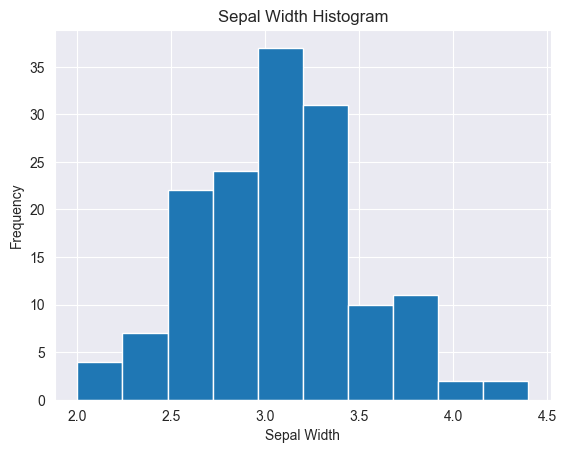

In [42]:
plt.hist(iris_df['sepal_width'], bins=10)
plt.title('Sepal Width Histogram')
plt.xlabel('Sepal Width')
plt.ylabel('Frequency')
plt.show()

### 1B: Based on the histogram from #1a, which would you expect to be higher, the mean or the median? Why?

### Answer: Mean, The data appears to be right skewed which happens when mean > median

### 1C: Confirm your answer to #1b by actually finding these values.

In [43]:
sepal_width_mean = iris_df['sepal_width'].mean()
sepal_width_median = iris_df['sepal_width'].median()

if(sepal_width_mean > sepal_width_median):
    print('The mean is larger')
else:
    print('The median is larger')
print(f'Sepal width mean: {sepal_width_mean}')
print(f'Sepal width median: {sepal_width_median}')


The mean is larger
Sepal width mean: 3.0573333333333337
Sepal width median: 3.0


### 1D: Only 27% of the flowers have a Sepal.Width higher than ________ cm.

In [44]:
sepal_width_27pct = iris_df['sepal_width'].quantile(.73)

print(f'Only 27% of the flowers have a Sepal.Width higher than {sepal_width_27pct} cm')


Only 27% of the flowers have a Sepal.Width higher than 3.3 cm


### 1E: Make scatterplots of each pair of the numerical variables in iris (There should be 6 pairs/plots).

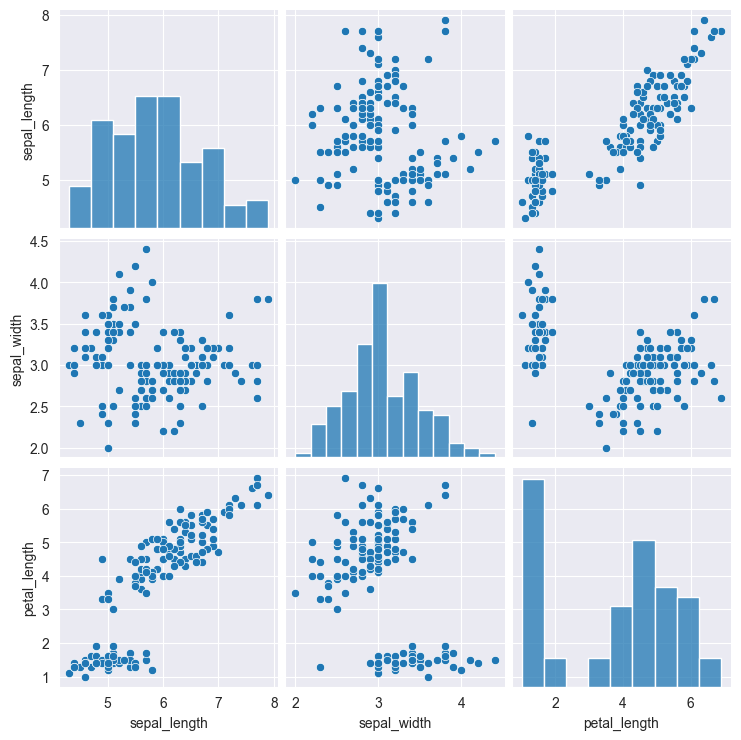

In [45]:
columns_to_plot = ['sepal_length', 'sepal_width', 'petal_length']

sns.pairplot(iris_df[columns_to_plot], markers='o')

plt.show()


### 1F: Based on #1e, which two variables appear to have the strongest relationship? And which two appear to have the weakest relationship?

### Answer: Sepal Length / Petal Length appear to have the strongest relationship and Sepal Length / Sepal Width appear to have the weakest relationship.

## 2: Using the PlantGrowth dataset...

### 2A: Make a histogram of the variable weight with breakpoints (bin edges) at every 0.3 units, starting at 3.3.

In [46]:
PlantGrowth['weight'].max()

np.float64(6.31)

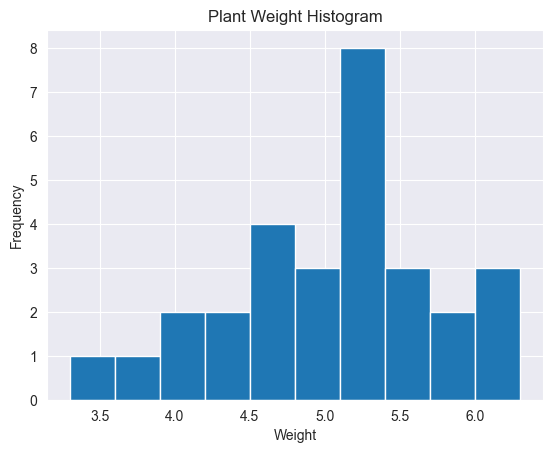

In [47]:
bins_breakpoints = np.arange(3.3, 6.6, .3) 
plt.hist(PlantGrowth['weight'], bins=bins_breakpoints)

plt.title('Plant Weight Histogram')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()

### 2B: Make boxplots of weight separated by group in a single graph.

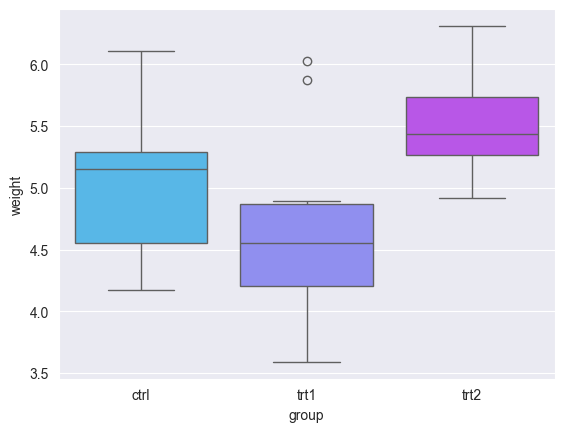

In [48]:
sns.set_style("darkgrid")
sns.boxplot(x='group', y='weight', data=PlantGrowth, palette='cool', hue='group')

plt.show()

### 2C: Based on the boxplots in #2b, approximately what percentage of the "trt1" weights are below the minimum "trt2" weight?

### Answer: A bit over 75%, The box in a box plot represents the middle 50% of the data. Since the entire box of trt1 falls below trt2 it means that the bottom 25% of data beneath it also fall below which puts the estimate at 75%. The top trt1 whisker above the box, also apears to fall below the bottom whisker of trt2 which I belive means at least 1 additional value exists above the 75th percentile.

### 2D: Find the exact percentage of the "trt1" weights that are below the minimum "trt2" weight.

In [49]:
trt2_min = PlantGrowth['weight'][PlantGrowth['group'] == 'trt2'].min()
print(f'trt2 minimum value is {trt2_min}')

print(PlantGrowth['weight'][PlantGrowth['group'] == 'trt1'].sort_values(ascending=False))

below_min_pct = np.mean(PlantGrowth['weight'][PlantGrowth['group'] == 'trt1'] < trt2_min) * 100
print(f"{below_min_pct:.2f}% of trt1 is below {trt2_min}")

trt2 minimum value is 4.92
16    6.03
14    5.87
17    4.89
10    4.81
19    4.69
12    4.41
18    4.32
11    4.17
15    3.83
13    3.59
Name: weight, dtype: float64
80.00% of trt1 is below 4.92


### This isn't my answer, I believe I misread the question at first and did the following code. I'm including it just in case!

In [50]:
trt2_qnts = PlantGrowth['weight'][PlantGrowth['group'] == 'trt2'].quantile([.25,.75]).values
print(f'trt2 Quartiles {trt2_qnts}')

trt2_iqr = trt2_qnts[1] - trt2_qnts[0]
print(f'trt2 IQR {trt2_iqr}')

trt2_limits = trt2_qnts + np.array([-1.5, 1.5]) * trt2_iqr

print(f'trt2 Lower Limit: {trt2_limits[0]}')

below_LL_pct = np.mean(PlantGrowth['weight'][PlantGrowth['group'] == 'trt1'] < trt2_limits[0]) * 100
print(f"{below_LL_pct:.2f}% of trt1 is below the lower limit of trt2")


trt2 Quartiles [5.2675 5.735 ]
trt2 IQR 0.46749999999999936
trt2 Lower Limit: 4.566250000000001
50.00% of trt1 is below the lower limit of trt2


### 2E: Only including plants with a weight above 5.5, make a barplot of the variable group. Make the barplot colorful using some color palette

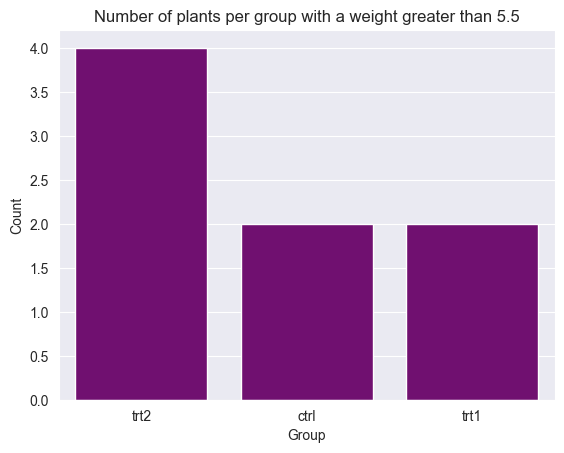

In [75]:
heavy_plants = PlantGrowth[PlantGrowth['weight'] > 5.5]

frequency_table = heavy_plants['group'].value_counts()

labels_int = frequency_table.index.tolist()
labels = list(map(str, labels_int))
values = frequency_table.values

sns.barplot(x=labels, y=values, color='Purple')

plt.title("Number of plants per group with a weight greater than 5.5")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

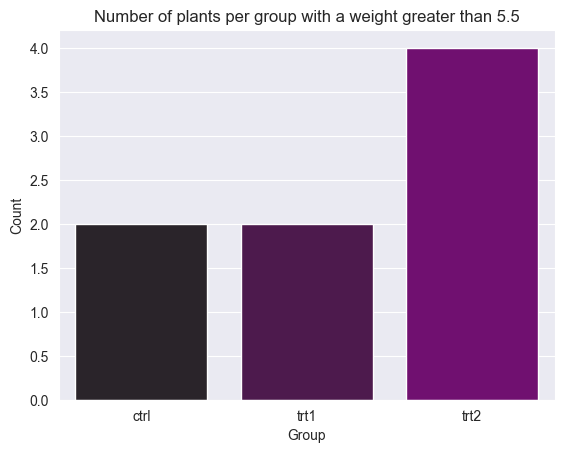

In [76]:
heavy_plants = PlantGrowth[PlantGrowth['weight'] > 5.5]

# frequency_table = heavy_plants['group'].value_counts()

# labels_int = frequency_table.index.tolist()
# labels = list(map(str, labels_int))
# values = frequency_table.values

sns.countplot(data=heavy_plants, x='group', palette='dark:Purple', hue='group')

plt.title("Number of plants per group with a weight greater than 5.5")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()
